Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Load the Dataset

In [2]:
data = pd.read_csv(
    "../datasets/diabetes_binary_health_indicators_BRFSS2015.csv"
)

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Explore the Dataset

In [3]:
print("Dataset Shape:", data.shape)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nMissing Values:")
print(data.isnull().sum().sum())

print("\nTarget Distribution:")
print(data["Diabetes_binary"].value_counts())

print("\nDataset Information:")
data.info()

Dataset Shape: (253680, 22)

Column Names:
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Missing Values:
0

Target Distribution:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke      

Target Distribution

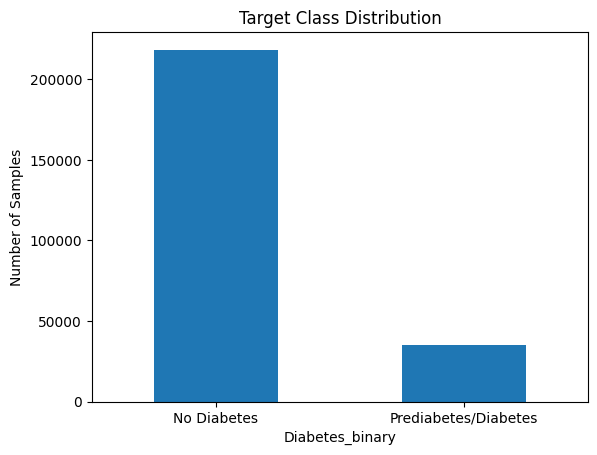

In [4]:
data["Diabetes_binary"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Diabetes_binary")
plt.ylabel("Number of Samples")
plt.title("Target Class Distribution")
plt.xticks([0, 1], ["No Diabetes", "Prediabetes/Diabetes"], rotation=0)
plt.show()

    The target variable is imbalanced, with considerably more samples
    belonging to class 0 than class 1.

    Although the original dataset is primarily intended for classification,
    the assignment requires regression algorithms. Therefore, the binary
    target is treated as a numerical response for the regression
    experiments.

Separate Features and Target

In [5]:
X = data.drop("Diabetes_binary", axis=1)
y = data["Diabetes_binary"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (253680, 21)
Target shape: (253680,)


Split the Dataset into Training and Testing Sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 202944
Testing samples : 50736


Initial Decision Tree Regressor

In [7]:
regressor = DecisionTreeRegressor(
    max_depth=3,
    min_samples_split=3,
    random_state=42
)

regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

Regression Evaluation

In [8]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Regression Metrics")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Regression Metrics
MAE : 0.2069857126523979
MSE : 0.10262095861873584
RMSE: 0.3203450617985797
R²  : 0.13684698254428063


Training vs Testing RMSE

In [9]:
y_train_pred = regressor.predict(X_train)

train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("Training RMSE:", train_rmse)
print("Testing RMSE :", test_rmse)

Training RMSE: 0.3226780752790033
Testing RMSE : 0.3203450617985797


Hyperparameter Tuning — Selecting max_depth

    The `max_depth` parameter controls the maximum depth of the decision tree.

    A small depth may cause underfitting because the tree is too simple.
    Increasing the depth allows the model to learn more complex patterns.

    However, excessive depth can cause overfitting.

    Therefore, several values of `max_depth` are tested while keeping
    the dataset split and other parameters fixed.

In [10]:
depths = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]

results = []

for depth in depths:

    model = DecisionTreeRegressor(
        max_depth=depth,
        min_samples_split=3,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    mae = mean_absolute_error(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)

    y_test_class = (y_test_pred >= 0.5).astype(int)

    accuracy = accuracy_score(y_test, y_test_class)
    precision = precision_score(y_test, y_test_class, zero_division=0)

    recall = recall_score(y_test, y_test_class, zero_division=0)

    f1 = f1_score(y_test, y_test_class, zero_division=0)

    results.append([
        depth,
        train_rmse,
        test_rmse,
        mae,
        mse,
        r2,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Max Depth",
        "Train RMSE",
        "Test RMSE",
        "MAE",
        "MSE",
        "R2",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

results_df

,Max Depth,Train RMSE,Test RMSE,MAE,MSE,R2,Accuracy,Precision,Recall,F1
0,2,0.326948,0.324571,0.212540,0.105346,0.113923,0.862090,0.000000,0.000000,0.000000
1,3,0.322678,0.320345,0.206986,0.102621,0.136847,0.862090,0.000000,0.000000,0.000000
2,4,0.319624,0.317078,0.203014,0.100539,0.154362,0.864002,0.517956,0.199943,0.288513
3,5,0.317079,0.314758,0.199933,0.099072,0.166695,0.866131,0.587532,0.098328,0.168462
4,6,0.315294,0.313079,0.197885,0.098019,0.175558,0.866131,0.587532,0.098328,0.168462
5,8,0.312187,0.312087,0.195148,0.097398,0.180775,0.866052,0.565133,0.124625,0.204215
6,10,0.307428,0.315318,0.194322,0.099425,0.163727,0.863568,0.522046,0.126912,0.204185
7,12,0.297602,0.324526,0.194279,0.105317,0.114172,0.857241,0.455175,0.178505,0.256442
8,15,0.268659,0.352753,0.196418,0.124435,-0.046633,0.840488,0.371362,0.226097,0.281070
9,20,0.194965,0.404181,0.201488,0.163363,-0.374055,0.809662,0.309456,0.308704,0.309079


Compare max_depth Values

In [11]:
results_df.sort_values(
    by="Test RMSE"
).reset_index(drop=True)

,Max Depth,Train RMSE,Test RMSE,MAE,MSE,R2,Accuracy,Precision,Recall,F1
0,8,0.312187,0.312087,0.195148,0.097398,0.180775,0.866052,0.565133,0.124625,0.204215
1,6,0.315294,0.313079,0.197885,0.098019,0.175558,0.866131,0.587532,0.098328,0.168462
2,5,0.317079,0.314758,0.199933,0.099072,0.166695,0.866131,0.587532,0.098328,0.168462
3,10,0.307428,0.315318,0.194322,0.099425,0.163727,0.863568,0.522046,0.126912,0.204185
4,4,0.319624,0.317078,0.203014,0.100539,0.154362,0.864002,0.517956,0.199943,0.288513
5,3,0.322678,0.320345,0.206986,0.102621,0.136847,0.862090,0.000000,0.000000,0.000000
6,12,0.297602,0.324526,0.194279,0.105317,0.114172,0.857241,0.455175,0.178505,0.256442
7,2,0.326948,0.324571,0.212540,0.105346,0.113923,0.862090,0.000000,0.000000,0.000000
8,15,0.268659,0.352753,0.196418,0.124435,-0.046633,0.840488,0.371362,0.226097,0.281070
9,20,0.194965,0.404181,0.201488,0.163363,-0.374055,0.809662,0.309456,0.308704,0.309079


    The results show that the testing RMSE initially decreases as the
    maximum depth increases.

    The lowest testing RMSE is obtained at `max_depth = 8`.

    After depth 8, the testing RMSE begins to increase even though the
    training RMSE continues to decrease. This indicates that the tree is
    starting to overfit the training data.

    Therefore, `max_depth = 8` is selected for the final Decision Tree
    Regressor.

Visualize the Effect of max_depth

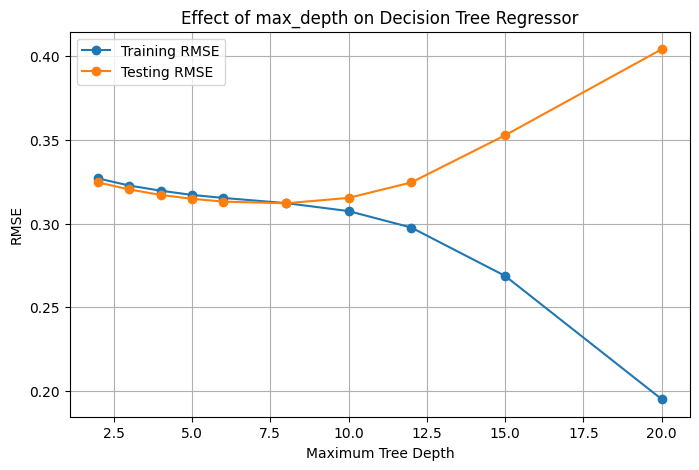

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Max Depth"],
    results_df["Train RMSE"],
    marker="o",
    label="Training RMSE"
)

plt.plot(
    results_df["Max Depth"],
    results_df["Test RMSE"],
    marker="o",
    label="Testing RMSE"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("RMSE")
plt.title("Effect of max_depth on Decision Tree Regressor")
plt.legend()
plt.grid(True)

plt.show()

Train the Final Decision Tree Regressor

In [13]:
final_regressor = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=3,
    random_state=42
)

final_regressor.fit(X_train, y_train)

y_pred = final_regressor.predict(X_test)

Final Regression Performance

In [14]:
final_mae = mean_absolute_error(y_test, y_pred)
final_mse = mean_squared_error(y_test, y_pred)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, y_pred)

y_train_pred = final_regressor.predict(X_train)

final_train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred)
)

print("Final Decision Tree Regressor\n")
print("Max Depth      :", 8)
print("Min Samples    :", 3)
print("\nTraining RMSE  :", final_train_rmse)
print("Testing RMSE   :", final_rmse)
print("MAE            :", final_mae)
print("MSE            :", final_mse)
print("R²             :", final_r2)

Final Decision Tree Regressor

Max Depth      : 8
Min Samples    : 3

Training RMSE  : 0.31218672639541023
Testing RMSE   : 0.31208697485573533
MAE            : 0.19514778498384236
MSE            : 0.09739827987460437
R²             : 0.1807753474501984


Final Classification Interpretation

In [15]:
y_pred_class = (y_pred >= 0.5).astype(int)

final_accuracy = accuracy_score(y_test, y_pred_class)

final_precision = precision_score(y_test,y_pred_class,zero_division=0)

final_recall = recall_score(y_test,y_pred_class,zero_division=0)

final_f1 = f1_score(y_test,y_pred_class,zero_division=0)

print("Classification Interpretation:")
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)

Classification Interpretation:
Accuracy : 0.8660517187007253
Precision: 0.5651328580686974
Recall   : 0.1246248392168072
F1 Score : 0.20421545667447308


Final Confusion Matrix

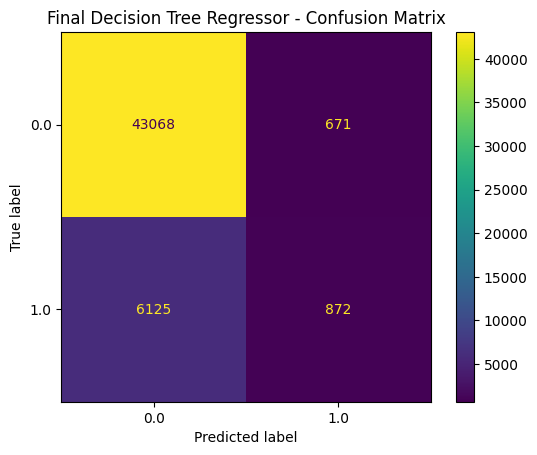

In [16]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_class)

plt.title("Final Decision Tree Regressor - Confusion Matrix")
plt.show()

Actual vs Predicted Values

In [17]:
comparison = pd.DataFrame(
    {
    "Actual": y_test.values,
    "Predicted Regression Output": y_pred,
    "Predicted Class": y_pred_class
})

comparison.head(50)

,Actual,Predicted Regression Output,Predicted Class
0,0.0,0.042882,0
1,0.0,0.312179,0
2,0.0,0.001992,0
3,0.0,0.006702,0
4,0.0,0.287714,0
5,0.0,0.450472,0
6,0.0,0.026171,0
7,0.0,0.121130,0
8,0.0,0.043935,0
9,0.0,0.074627,0


Decision Tree Display

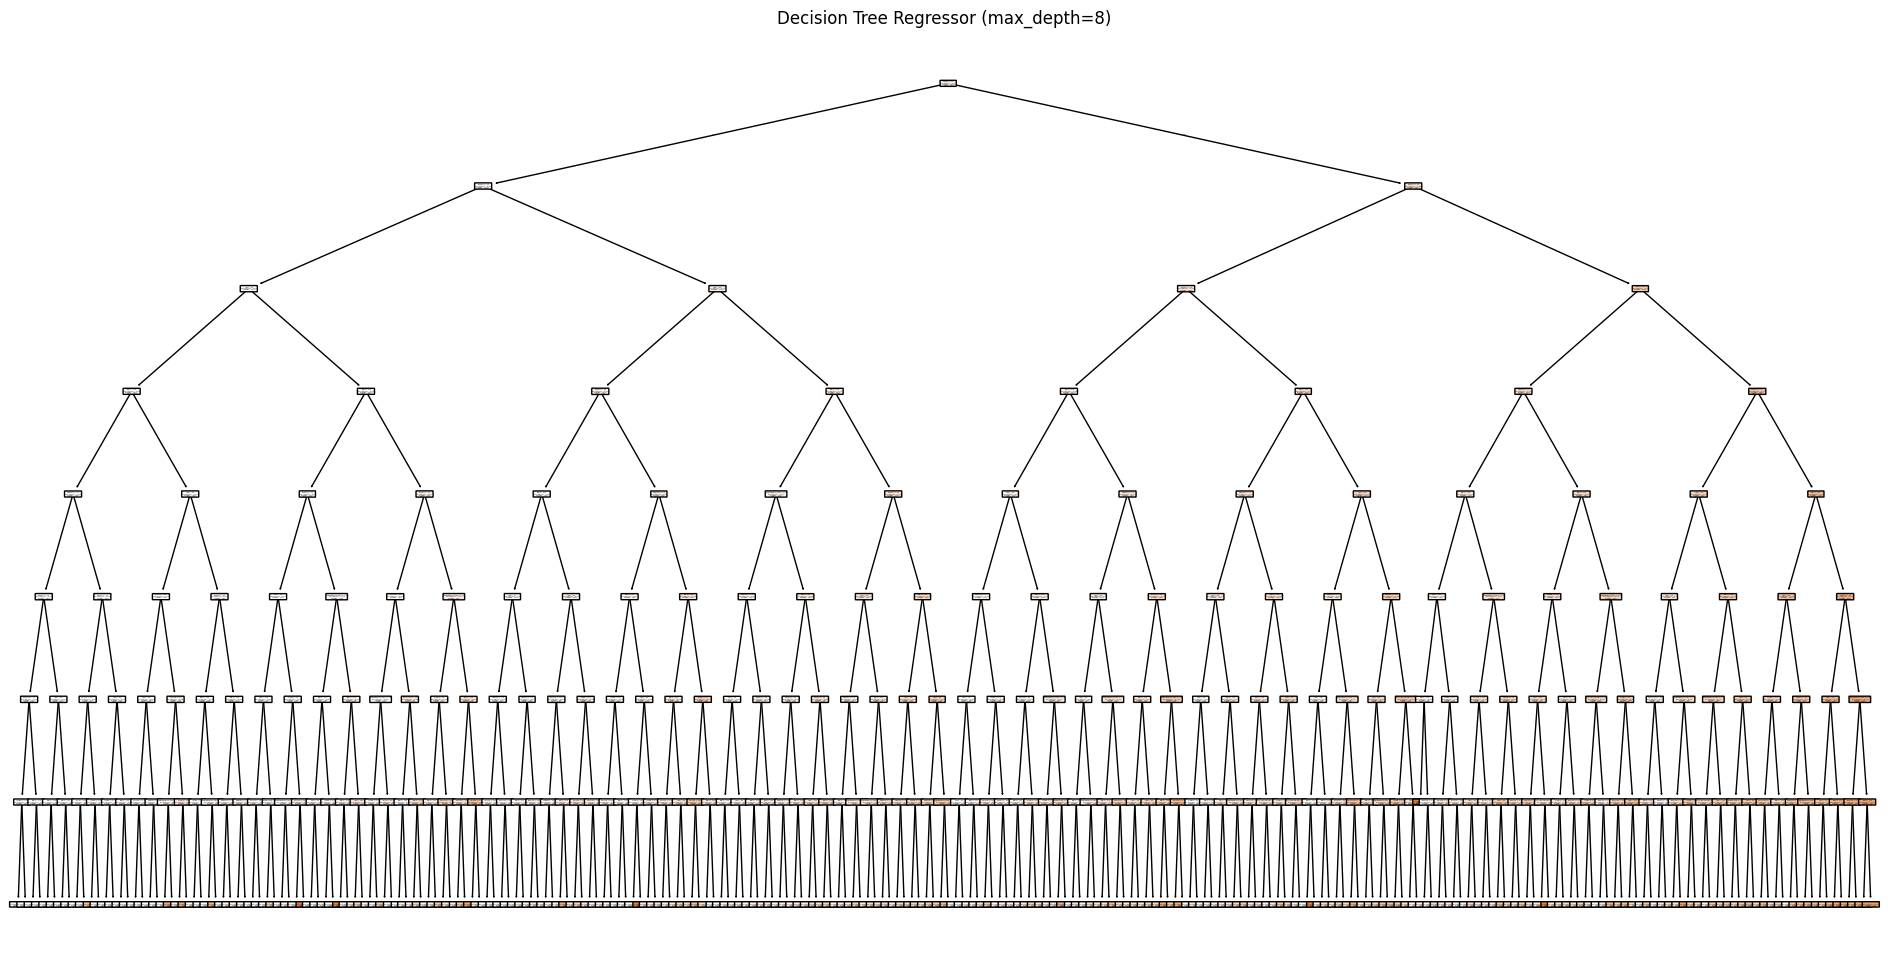

In [18]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))

plot_tree(
    final_regressor,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    precision=3
)

plt.title("Decision Tree Regressor (max_depth=8)")
plt.show()

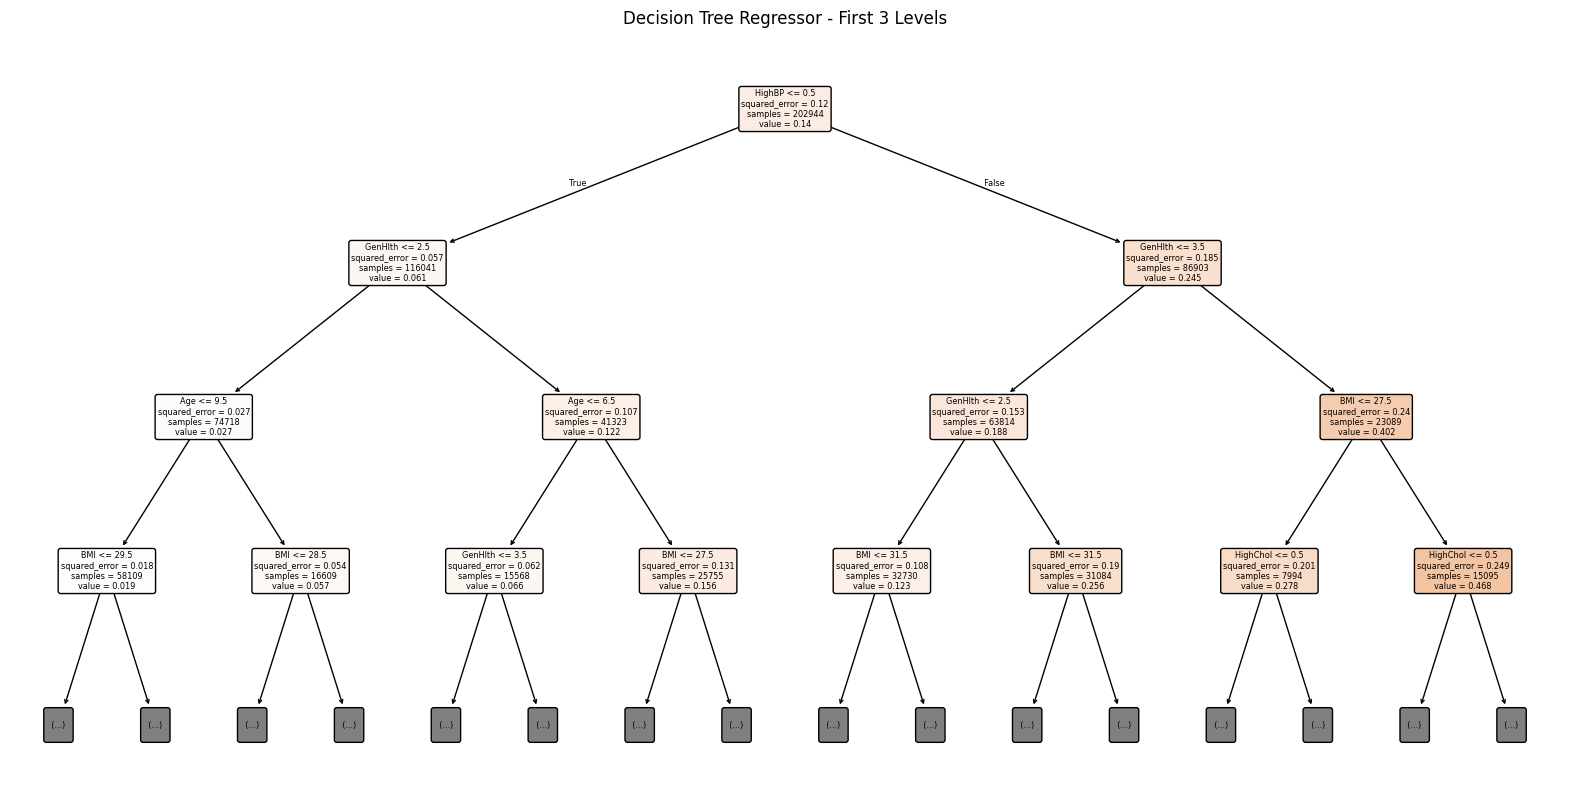

In [19]:
plt.figure(figsize=(20, 10))

plot_tree(
    final_regressor,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    precision=3,
    max_depth=3
)

plt.title("Decision Tree Regressor - First 3 Levels")
plt.show()